In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()


In [2]:
df_raw = df.copy()
df_india = df_raw[df_raw['job_country']=='India'].dropna(subset = ['salary_year_avg'])
df_india

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1209,Machine Learning Engineer,Computer Vision Developer (R&D),"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-02-18 13:12:30,False,False,India,year,79200.0,NaN,Bosch Group,"['python', 'opencv', 'tensorflow', 'pytorch', ...","{'libraries': ['opencv', 'tensorflow', 'pytorc..."
2022,Data Engineer,Data Engineer - SQL (Power BI),India,via Ai-Jobs.net,Full-time,False,India,2023-10-31 13:09:54,False,False,India,year,156500.0,NaN,Gartner,"['java', 't-sql', 'sql', 'azure', 'power bi', ...","{'analyst_tools': ['power bi', 'dax'], 'async'..."
2785,Data Engineer,Staff Software Engineer - Data Engineering (Ja...,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-05-26 13:13:28,False,False,India,year,147500.0,NaN,Zscaler,"['java', 'nosql', 'neo4j', 'redshift', 'aws', ...","{'analyst_tools': ['excel'], 'cloud': ['redshi..."
3190,Senior Data Engineer,Senior Big Data DevOps & Deployment Engineer,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-07-07 13:14:21,False,False,India,year,79200.0,NaN,ServiceNow,"['sql', 'perl', 'bash', 'groovy', 'python', 's...","{'analyst_tools': ['tableau'], 'cloud': ['azur..."
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,"['python', 'r', 'c++', 'tensorflow', 'tableau']","{'analyst_tools': ['tableau'], 'libraries': ['..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783733,Senior Data Scientist,Senior Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-06-27 06:12:11,False,False,India,year,157500.0,NaN,Publicis Groupe,"['aws', 'spark', 'tableau', 'cognos', 'excel',...","{'analyst_tools': ['tableau', 'cognos', 'excel..."
784033,Data Analyst,Recruitment Data Analyst,"Mumbai, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-06-07 06:10:15,False,False,India,year,111175.0,NaN,Framestore,"['power bi', 'tableau']","{'analyst_tools': ['power bi', 'tableau']}"
784768,Data Scientist,SR. DATA SCIENTIST,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-01-03 06:25:25,False,False,India,year,157500.0,NaN,Optiv,"['r', 'python', 'sql', 'databricks', 'power bi']","{'analyst_tools': ['power bi'], 'cloud': ['dat..."
785395,Data Engineer,Senior Consultant - Tech Consulting -Azure Dat...,India,via Ai-Jobs.net,Full-time,False,India,2023-12-19 06:10:41,False,False,India,year,64800.0,NaN,EY,"['sql', 'python', 'azure', 'databricks', 'spar...","{'analyst_tools': ['power bi', 'tableau', 'qli..."


In [3]:
df_india_topjobs = df_india['job_title_short'].value_counts().index[:5].tolist()
df_india_topjobs
df_top_salaryindia = df_india[df_india['job_title_short'].isin(df_india_topjobs)]

In [4]:
df_top_salary_jobs = df_top_salaryindia.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending = False).index
df_top_salary_jobs



Index(['Senior Data Engineer', 'Data Engineer', 'Data Scientist',
       'Data Analyst', 'Machine Learning Engineer'],
      dtype='object', name='job_title_short')

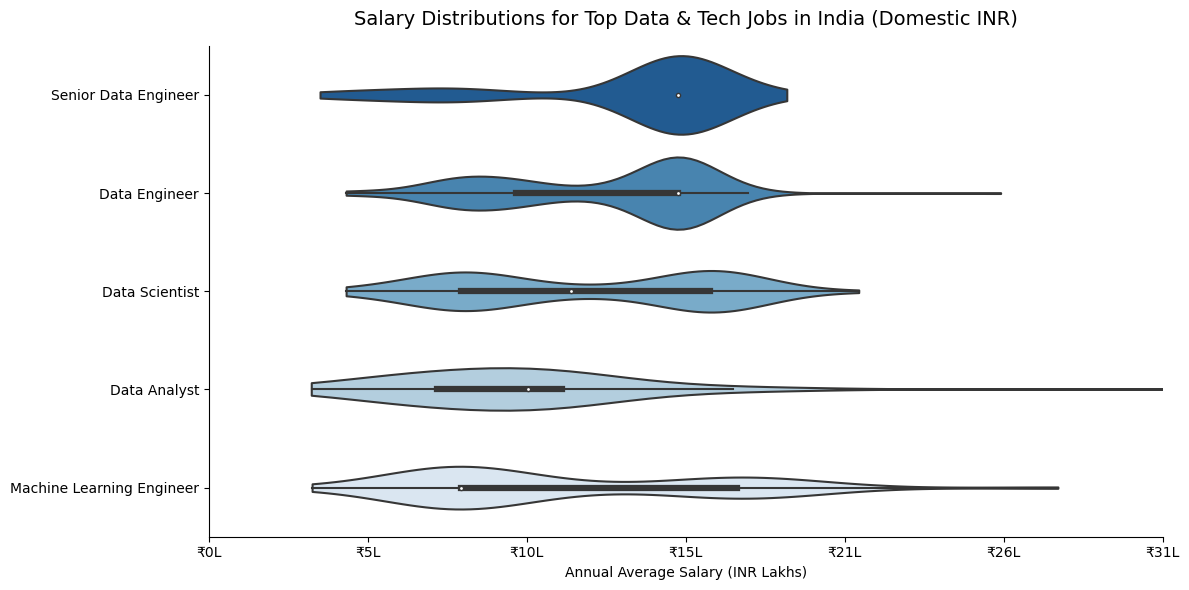

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Normalize and Calibrate:
PPP_FACTOR = 23.5 / 100000
DOMESTIC_RATIO = 0.447
EFFECTIVE_DOMESTIC_FACTOR = PPP_FACTOR * DOMESTIC_RATIO  # ~10.5 / 100000

fig, ax = plt.subplots(figsize=(12, 6))

# Plotting Violin Chart:
sns.violinplot(
    data=df_top_salaryindia,
    x='salary_year_avg',
    y='job_title_short',
    order=df_top_salary_jobs,
    ax=ax,
    palette='Blues_r',
    cut=0
)

plt.title('Salary Distributions for Top Data & Tech Jobs in India (Domestic INR)', fontsize=14, pad=15)
plt.xlabel('Annual Average Salary (INR Lakhs)')
plt.ylabel('')

plt.xlim(0, 300000) 
ticks_x = mtick.FuncFormatter(lambda y, pos: f"₹{int(y * EFFECTIVE_DOMESTIC_FACTOR)}L")
ax.xaxis.set_major_formatter(ticks_x)

sns.despine()
plt.tight_layout()
plt.savefig('my_plot_ds.png', facecolor='white', edgecolor='none', transparent=False, bbox_inches='tight', dpi=300)
plt.show()

In [6]:
import ast
import pandas as pd

df_india_clean = df_india.copy()

# 1. Safely parse strings to real python lists BEFORE exploding them
df_india_clean['job_skills'] = df_india_clean['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


In [7]:
df_india_explode = df_india_clean.explode('job_skills')
df_india_explode

df_india_ds = df_india_explode[df_india_explode['job_title_short']=='Data Scientist']
df_india_ds

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,python,"{'analyst_tools': ['tableau'], 'libraries': ['..."
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,r,"{'analyst_tools': ['tableau'], 'libraries': ['..."
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,c++,"{'analyst_tools': ['tableau'], 'libraries': ['..."
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,tensorflow,"{'analyst_tools': ['tableau'], 'libraries': ['..."
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,tableau,"{'analyst_tools': ['tableau'], 'libraries': ['..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784768,Data Scientist,SR. DATA SCIENTIST,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-01-03 06:25:25,False,False,India,year,157500.0,NaN,Optiv,r,"{'analyst_tools': ['power bi'], 'cloud': ['dat..."
784768,Data Scientist,SR. DATA SCIENTIST,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-01-03 06:25:25,False,False,India,year,157500.0,NaN,Optiv,python,"{'analyst_tools': ['power bi'], 'cloud': ['dat..."
784768,Data Scientist,SR. DATA SCIENTIST,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-01-03 06:25:25,False,False,India,year,157500.0,NaN,Optiv,sql,"{'analyst_tools': ['power bi'], 'cloud': ['dat..."
784768,Data Scientist,SR. DATA SCIENTIST,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-01-03 06:25:25,False,False,India,year,157500.0,NaN,Optiv,databricks,"{'analyst_tools': ['power bi'], 'cloud': ['dat..."


In [8]:
df_india_ds_topskills = df_india_ds.groupby('job_skills')['salary_year_avg'].agg(median_value = 'median', skill_count = 'size')
df_india_ds_topskills.sort_values(by = 'skill_count', ascending = False).head(7)


,median_value,skill_count
job_skills,,
python,152500.0,64
sql,113500.0,49
r,129758.0,30
spark,93600.0,23
aws,103550.0,20
tableau,113500.0,19
tensorflow,136008.0,16


In [9]:
df_india_ds_payskills = df_india_ds.groupby('job_skills')['salary_year_avg'].agg(median_value = 'median', skill_count = 'size').copy()
df_india_ds_payskillsplot = df_india_ds_payskills.query('skill_count >= 9').sort_values(by='median_value', ascending=False)
df_india_ds_payskillsplot.head(7)



,median_value,skill_count
job_skills,,
azure,157500.0,15
pytorch,157500.0,10
python,152500.0,64
tensorflow,136008.0,16
r,129758.0,30
keras,122602.5,10
sql,113500.0,49


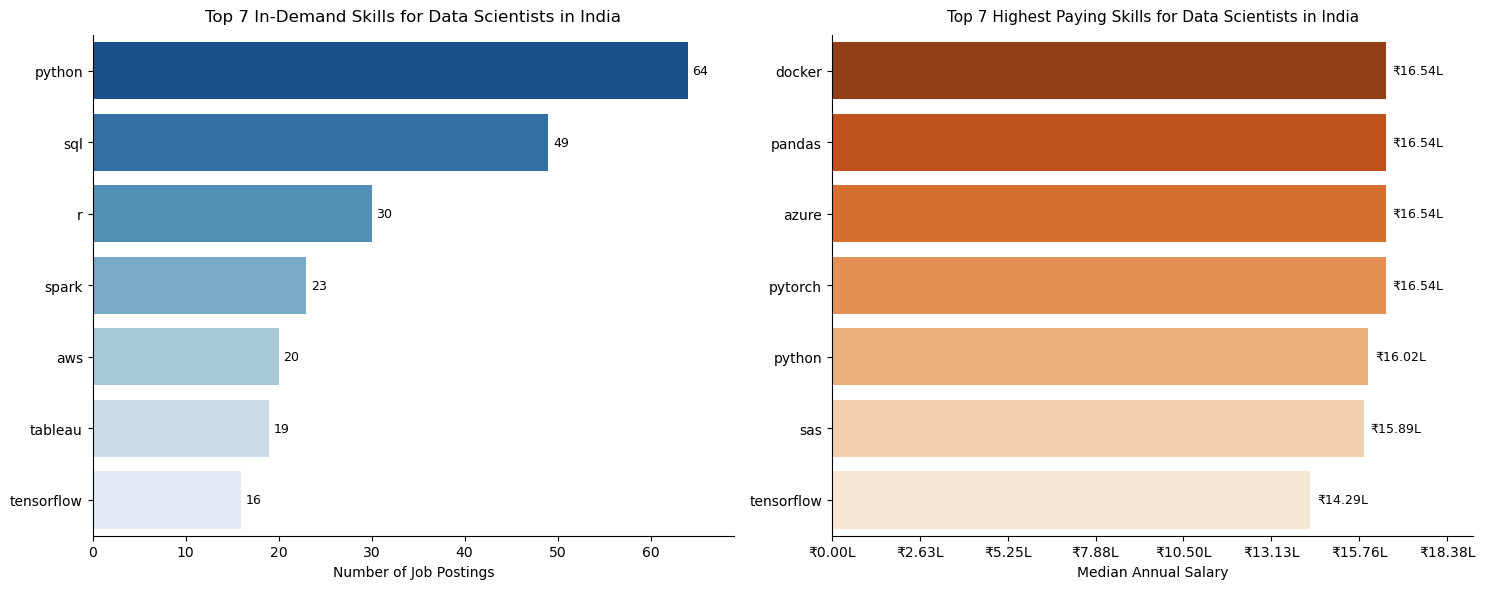

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

#For indemand skills
df_india_ds_topskills = df_india_ds.groupby('job_skills')['salary_year_avg'].agg(median_value = 'median', skill_count = 'size')

#for highpaying skills
df_india_ds_payskills = df_india_ds.groupby('job_skills')['salary_year_avg'].agg(median_value = 'median', skill_count = 'size').copy()
df_india_ds_payskillsplot = df_india_ds_payskills.query('skill_count >= 8').sort_values(by='median_value', ascending=False)

# Prepare top 7 for bars visualization
df_demand_plot = df_india_ds_topskills.sort_values(by='skill_count', ascending=False).head(7).reset_index()
df_pay_plot = df_india_ds_payskillsplot.head(7).reset_index()

# 2. PPP + Domestic Market salary range conversion
PPP_FACTOR = 23.5 / 100000
DOMESTIC_RATIO = 0.447
EFFECTIVE_DOMESTIC_FACTOR = PPP_FACTOR * DOMESTIC_RATIO  # ~10.5 / 100000

# 3. Layout
fig, ax = plt.subplots(1, 2, figsize=(15, 6))


sns.barplot(
    data=df_demand_plot,
    x='skill_count',
    y='job_skills',
    ax=ax[0],
    palette='Blues_r'
)
ax[0].set_title("Top 7 In-Demand Skills for Data Scientists in India", fontsize=12, pad=10)
ax[0].set_xlabel("Number of Job Postings")
ax[0].set_ylabel("")

# Labelling:
for index, value in enumerate(df_demand_plot['skill_count']):
    ax[0].text(value + 0.5, index, f'{int(value)}', va='center', ha='left', fontsize=9)

#Skills added labels:
sns.barplot(
    data=df_pay_plot,
    x='median_value',
    y='job_skills',
    ax=ax[1],
    palette='Oranges_r'
)
ax[1].set_title("Top 7 Highest Paying Skills for Data Scientists in India", fontsize=11, pad=10)
ax[1].set_xlabel("Median Annual Salary")
ax[1].set_ylabel("")

ticks_x = mtick.FuncFormatter(lambda y, pos: f'₹{y * EFFECTIVE_DOMESTIC_FACTOR:.2f}L')
ax[1].xaxis.set_major_formatter(ticks_x)

for index, value in enumerate(df_pay_plot['median_value']):
    ax[1].text(value + 2000, index, f'₹{value * EFFECTIVE_DOMESTIC_FACTOR:.2f}L', va='center', ha='left', fontsize=9)

#Preventing labels from coming together or merging
ax[0].set_xlim(0, df_demand_plot['skill_count'].max() + 5)
ax[1].set_xlim(0, df_pay_plot['median_value'].max() + 25000)

# Clean borders and plot making:
sns.despine()
plt.tight_layout()
plt.savefig('my_plot_ds.png', facecolor='white', edgecolor='none', transparent=False, bbox_inches='tight', dpi=300)
plt.show()

In [11]:
df_india_explode = df_india_clean.explode('job_skills')
df_india_explode

df_india_da = df_india_explode[df_india_explode['job_title_short']=='Data Analyst']
df_india_da

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
11412,Data Analyst,Data Quality Analyst,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-03-15 13:12:15,False,False,India,year,50400.0,NaN,IntegriChain,python,"{'analyst_tools': ['excel'], 'cloud': ['aws', ..."
11412,Data Analyst,Data Quality Analyst,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-03-15 13:12:15,False,False,India,year,50400.0,NaN,IntegriChain,sql,"{'analyst_tools': ['excel'], 'cloud': ['aws', ..."
11412,Data Analyst,Data Quality Analyst,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-03-15 13:12:15,False,False,India,year,50400.0,NaN,IntegriChain,aws,"{'analyst_tools': ['excel'], 'cloud': ['aws', ..."
11412,Data Analyst,Data Quality Analyst,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-03-15 13:12:15,False,False,India,year,50400.0,NaN,IntegriChain,azure,"{'analyst_tools': ['excel'], 'cloud': ['aws', ..."
11412,Data Analyst,Data Quality Analyst,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-03-15 13:12:15,False,False,India,year,50400.0,NaN,IntegriChain,excel,"{'analyst_tools': ['excel'], 'cloud': ['aws', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777313,Data Analyst,Data Analyst,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-01-10 05:12:09,False,False,India,year,111202.0,NaN,Poshmark,looker,"{'analyst_tools': ['excel', 'looker', 'powerpo..."
777313,Data Analyst,Data Analyst,"Pune, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-01-10 05:12:09,False,False,India,year,111202.0,NaN,Poshmark,powerpoint,"{'analyst_tools': ['excel', 'looker', 'powerpo..."
784033,Data Analyst,Recruitment Data Analyst,"Mumbai, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-06-07 06:10:15,False,False,India,year,111175.0,NaN,Framestore,power bi,"{'analyst_tools': ['power bi', 'tableau']}"
784033,Data Analyst,Recruitment Data Analyst,"Mumbai, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-06-07 06:10:15,False,False,India,year,111175.0,NaN,Framestore,tableau,"{'analyst_tools': ['power bi', 'tableau']}"


In [12]:
df_india_da_topskills = df_india_ds.groupby('job_skills')['salary_year_avg'].agg(median_value = 'median', skill_count = 'size')
df_india_da_topskills.sort_values(by = 'skill_count', ascending = False).head(7)


,median_value,skill_count
job_skills,,
python,152500.0,64
sql,113500.0,49
r,129758.0,30
spark,93600.0,23
aws,103550.0,20
tableau,113500.0,19
tensorflow,136008.0,16


In [13]:
df_india_da_payskills = df_india_da.groupby('job_skills')['salary_year_avg'].agg(median_value = 'median', skill_count = 'size').copy()
df_india_da_payskillsplot = df_india_da_payskills.query('skill_count >=11').sort_values(by='median_value', ascending=False)
df_india_da_payskillsplot.head(7)



,median_value,skill_count
job_skills,,
power bi,111175.0,17
spark,111175.0,11
tableau,108087.5,20
excel,98500.0,39
python,96050.0,36
sql,96050.0,46
azure,93600.0,15


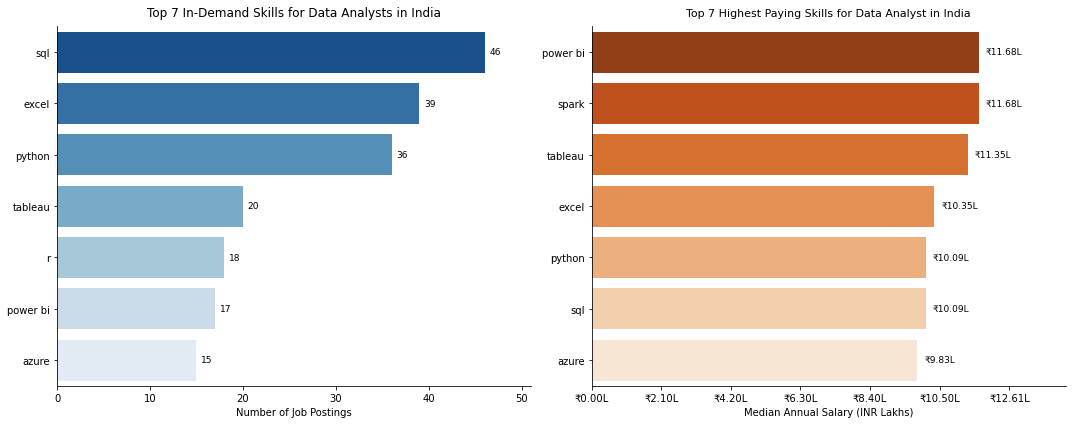

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

#For in demand skills
df_india_da_topskills = df_india_da.groupby('job_skills')['salary_year_avg'].agg(median_value = 'median', skill_count = 'size')

#for high paying skills
df_india_da_payskills = df_india_da.groupby('job_skills')['salary_year_avg'].agg(median_value = 'median', skill_count = 'size').copy()
df_india_da_payskillsplot = df_india_da_payskillsplot.query('skill_count >= 8').sort_values(by='median_value', ascending=False)

# Prepare top 7 for bars visualization
df_demand_plot = df_india_da_topskills.sort_values(by='skill_count', ascending=False).head(7).reset_index()
df_pay_plot = df_india_da_payskillsplot.head(7).reset_index()

# 2. PPP + Domestic Market salary range conversion
PPP_FACTOR = 23.5 / 100000
DOMESTIC_RATIO = 0.447
EFFECTIVE_DOMESTIC_FACTOR = PPP_FACTOR * DOMESTIC_RATIO  # ~10.5 / 100000

# 3. Layout
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

#  Top in-demand skills:
sns.barplot(
    data=df_demand_plot,
    x='skill_count',
    y='job_skills',
    ax=ax[0],
    palette='Blues_r'
)
ax[0].set_title("Top 7 In-Demand Skills for Data Analysts in India", fontsize=12, pad=10)
ax[0].set_xlabel("Number of Job Postings")
ax[0].set_ylabel("")

# Labelling:
for index, value in enumerate(df_demand_plot['skill_count']):
    ax[0].text(value + 0.5, index, f'{int(value)}', va='center', ha='left', fontsize=9)

# Median Value of skills:
sns.barplot(
    data=df_pay_plot,
    x='median_value',
    y='job_skills',
    ax=ax[1],
    palette='Oranges_r'
)
ax[1].set_title("Top 7 Highest Paying Skills for Data Analyst in India", fontsize=11, pad=10)
ax[1].set_xlabel("Median Annual Salary (INR Lakhs)")
ax[1].set_ylabel("")


ticks_x = mtick.FuncFormatter(lambda y, pos: f'₹{y * EFFECTIVE_DOMESTIC_FACTOR:.2f}L')
ax[1].xaxis.set_major_formatter(ticks_x)

for index, value in enumerate(df_pay_plot['median_value']):
    ax[1].text(value + 2000, index, f'₹{value * EFFECTIVE_DOMESTIC_FACTOR:.2f}L', va='center', ha='left', fontsize=9)

ax[0].set_xlim(0, df_demand_plot['skill_count'].max() + 5)
ax[1].set_xlim(0, df_pay_plot['median_value'].max() + 25000)

sns.despine()
plt.tight_layout()
plt.show()